# Semantic Image Search with CLIP — Day 12 (Architectures Toolbox)

Type a phrase like *"a cat on a couch"* and get back the photos that match its **meaning**,
not a filename. Built on **CLIP**, which maps text and images into one vector space, so a
sentence can be compared to pictures by cosine similarity.

**Pipeline:** stream real photos (Flickr30k) → embed each with CLIP → search by text →
draw a 2D map → measure accuracy → export an index and a small Streamlit app.

Same recurring move as the toolbox notebook (*model → embedding → explore*); the one change
is CLIP instead of ResNet18, because ResNet embeds images only and can't take a text query.


## Section 0 — Setup

Install the extras this notebook needs:

- **open_clip_torch** — the CLIP model (text + image encoders in one space).
- **datasets** — to *stream* Flickr30k (we pull ~1500 photos, not the full 31k set).
- **umap-learn**, **streamlit**, plus the usual pillow / tqdm / matplotlib.

### GPU (optional, recommended on this laptop — RTX 3050)
Run this notebook in **Anaconda3** (Python 3.13 here — new enough for the CUDA wheels).
Plain `pip install torch` on Windows gives a **CPU-only** build; for the GPU install the
CUDA build **first** from PyTorch's own index (uncomment the GPU cell below), then the rest.
Tip: a clean env keeps things tidy — `conda create -n clip-search python=3.11 -y` then
`conda activate clip-search` (base also works). On Colab / any machine that already has CUDA
torch, skip the GPU cell. Everything runs on CPU too, just slower to index.


In [1]:
# OPTIONAL — run ONCE for GPU (Windows + NVIDIA, Python 3.10+). Skip on Colab / existing CUDA torch.
# cu128 supports the RTX 3050 (Ampere). Older driver? swap cu128 -> cu126.
# Keep the --index-url on THIS line only (numpy/scipy/etc. live on PyPI, not this index).
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [2]:
# Core deps from PyPI. Safe on top of an existing torch (pip won't downgrade a CUDA build).
%pip install -q open_clip_torch datasets umap-learn streamlit pillow tqdm matplotlib
print("deps installed. If pip just upgraded numpy/scipy, do Kernel -> Restart before continuing.")

Note: you may need to restart the kernel to use updated packages.
deps installed. If pip just upgraded numpy/scipy, do Kernel -> Restart before continuing.


### Health check + device
Pick the best device (the NVIDIA GPU if present, else CPU) and confirm the imports work.


In [3]:
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")  # harmless on Windows; helps on Mac

import numpy as np
import torch
import open_clip

def pickDevice():
    "the apple gpu (mps) if present, else a cuda gpu, else the cpu"
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

device = pickDevice()
print("torch:", torch.__version__, "| cuda build:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("device:", device)

C:\Users\rasul\.conda\envs\clip-search\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.12.1+cpu | cuda build: None
cuda available: False
device: cpu


### Settings
Start small (fast), then raise `N_IMAGES` to scale up.


In [4]:
from pathlib import Path

N_IMAGES   = 1500          # Flickr30k photos to pull (streamed, not the full 31k)
BATCH      = 32            # embedding batch size (drop to 16/8 if 4 GB VRAM is tight)
MODEL_NAME = "ViT-B-32"
PRETRAINED = "laion2b_s34b_b79k"   # good default, no QuickGELU warning; ~605 MB, downloads once

IMAGES_DIR  = Path("images")
OUTPUTS_DIR = Path("outputs")
IMAGES_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)
print("using", N_IMAGES, "images | model", MODEL_NAME, "/", PRETRAINED, "| device", device)

using 1500 images | model ViT-B-32 / laion2b_s34b_b79k | device cpu


## Section 1 — Load CLIP (maps text AND images into one space)

`create_model_and_transforms` returns **three** things: the model, a *train* transform, and
a *val* transform. We keep the **val** transform for inference (no random augmentation).
CLIP features are **not** L2-normalized by default, so we normalize them — then cosine
similarity is just a dot product.


In [5]:
model, _, preprocess = open_clip.create_model_and_transforms(
    MODEL_NAME, pretrained=PRETRAINED, device=device
)                                    # 3 values; the middle one is the train transform (unused)
model.eval()
tokenizer = open_clip.get_tokenizer(MODEL_NAME)
print("CLIP ready:", MODEL_NAME, "/", PRETRAINED, "on", device)

CLIP ready: ViT-B-32 / laion2b_s34b_b79k on cpu


### Embedding helpers
Turn images and text into L2-normalized 512-d vectors. Batched, with a tqdm bar.


In [6]:
from PIL import Image
from tqdm.auto import tqdm

@torch.no_grad()
def embed_image_paths(paths, batch=BATCH):
    "load images from disk and embed them -> L2-normalized (N, 512) float32 array"
    vecs = []
    for i in tqdm(range(0, len(paths), batch), desc="image2vec"):
        pil = [Image.open(p).convert("RGB") for p in paths[i:i + batch]]
        x = torch.stack([preprocess(im) for im in pil]).to(device)
        f = model.encode_image(x).float()
        f = f / f.norm(dim=-1, keepdim=True)      # L2-normalize -> cosine == dot product
        vecs.append(f.cpu().numpy())
    return np.concatenate(vecs, axis=0).astype("float32")

@torch.no_grad()
def embed_texts(texts, batch=256):
    "embed a list of strings -> L2-normalized (N, 512) float32 array"
    vecs = []
    for i in range(0, len(texts), batch):
        tok = tokenizer(texts[i:i + batch]).to(device)
        f = model.encode_text(tok).float()
        f = f / f.norm(dim=-1, keepdim=True)
        vecs.append(f.cpu().numpy())
    return np.concatenate(vecs, axis=0).astype("float32")

def embed_text(query):
    "embed one query string -> L2-normalized (512,) vector"
    return embed_texts([query])[0]

## Section 2 — Stream Flickr30k and save the sample

We **stream** the dataset (`streaming=True`) and `.take(N_IMAGES)`, so only the photos we
use come over the network — not the full multi-GB set. Each row gives a PIL image and 5
human captions. We save each image to `images/` (so the app can show it later) and keep its
first caption (used by the evaluation in Section 6).


In [7]:
from datasets import load_dataset

# revision="refs/convert/parquet" loads HuggingFace's auto-converted Parquet copy. We need it
# because datasets>=4 dropped loading scripts and this repo ships a flickr30k.py script; the
# Parquet copy has the SAME schema (image -> PIL, caption -> list of 5) and streams fine.
stream = load_dataset("nlphuji/flickr30k", revision="refs/convert/parquet",
                      split="test", streaming=True)

paths, captions = [], []
for i, ex in enumerate(tqdm(stream.take(N_IMAGES), total=N_IMAGES, desc="download")):
    try:
        img = ex["image"].convert("RGB")     # ex["image"] is already a PIL image
    except Exception:
        continue                             # skip any image that fails to decode
    p = IMAGES_DIR / f"img_{i:05d}.jpg"
    img.save(p, "JPEG", quality=90)
    paths.append(p.as_posix())               # forward slashes -> portable (Windows + Colab)
    captions.append(ex["caption"][0])        # first of the 5 human captions

print("saved", len(paths), "images to", IMAGES_DIR)

download:   0%|          | 0/1500 [00:00<?, ?it/s]

download:   0%|          | 1/1500 [00:14<5:58:29, 14.35s/it]

download:   2%|▏         | 33/1500 [00:14<07:35,  3.22it/s] 

download:   4%|▍         | 65/1500 [00:14<03:08,  7.60it/s]

download:   6%|▋         | 95/1500 [00:14<01:45, 13.28it/s]

...

download:  96%|█████████▌| 1437/1500 [01:32<00:01, 32.97it/s]

download:  98%|█████████▊| 1468/1500 [01:32<00:00, 45.01it/s]

download: 100%|█████████▉| 1499/1500 [01:32<00:00, 57.66it/s]

download: 100%|██████████| 1500/1500 [01:43<00:00, 14.55it/s]

saved 1500 images to images


## Section 3 — Embed every image (one-time indexing)

This is the slow step and it runs **once**. On the RTX 3050 it is seconds; on CPU a minute
or two. We save the vectors in Section 7 so search never repeats this.


In [8]:
img_vectors = embed_image_paths(paths)
print("embedded", img_vectors.shape[0], "images into", img_vectors.shape[1], "dims")

image2vec:   0%|          | 0/47 [00:00<?, ?it/s]

image2vec:   2%|▏         | 1/47 [00:01<01:11,  1.55s/it]

image2vec:   4%|▍         | 2/47 [00:03<01:08,  1.52s/it]

image2vec:   6%|▋         | 3/47 [00:04<01:07,  1.53s/it]

image2vec:   9%|▊         | 4/47 [00:06<01:05,  1.51s/it]

...

image2vec:  96%|█████████▌| 45/47 [01:07<00:02,  1.48s/it]

image2vec:  98%|█████████▊| 46/47 [01:09<00:01,  1.47s/it]

image2vec: 100%|██████████| 47/47 [01:10<00:00,  1.42s/it]

image2vec: 100%|██████████| 47/47 [01:10<00:00,  1.50s/it]

embedded 1500 images into 512 dims


## Section 4 — Search by text (the core)

`cosineNeighbors` is copied from the toolbox notebook — it ranks vectors by cosine
similarity to a query vector. We feed it the **text** query vector and the **image**
vectors; it returns the closest images. Because the images are pre-embedded, each search is
instant (embed a short string + one dot product).


In [9]:
import matplotlib.pyplot as plt

def cosineNeighbors(query_vec, vectors, labels, topn=5):
    "return the topn labels whose vectors are closest to query_vec by cosine"
    q = query_vec / (np.linalg.norm(query_vec) + 1e-9)
    m = vectors / (np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-9)
    scores = m @ q
    order = np.argsort(-scores)[:topn]
    return [(labels[i], float(scores[i])) for i in order]

def search(query, topn=5):
    "text query -> list of (image_path, score)"
    return cosineNeighbors(embed_text(query), img_vectors, paths, topn)

def show_results(query, topn=5):
    hits = search(query, topn)
    fig, axes = plt.subplots(1, len(hits), figsize=(3 * len(hits), 3.2))
    if len(hits) == 1:
        axes = [axes]
    for ax, (p, s) in zip(axes, hits):
        ax.imshow(Image.open(p))
        ax.axis("off")
        ax.set_title(f"{s:.3f}", fontsize=9)
    fig.suptitle(f'query: "{query}"', fontsize=12)
    plt.tight_layout()
    plt.show()

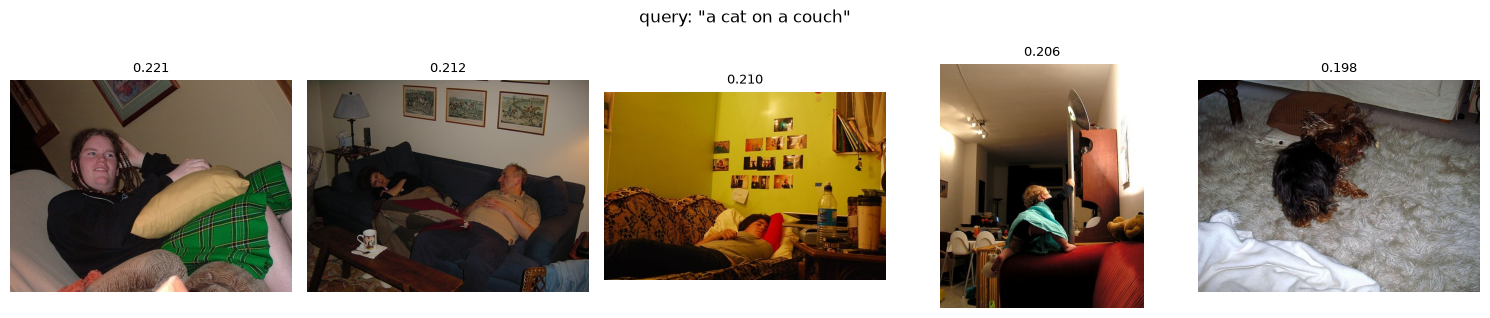

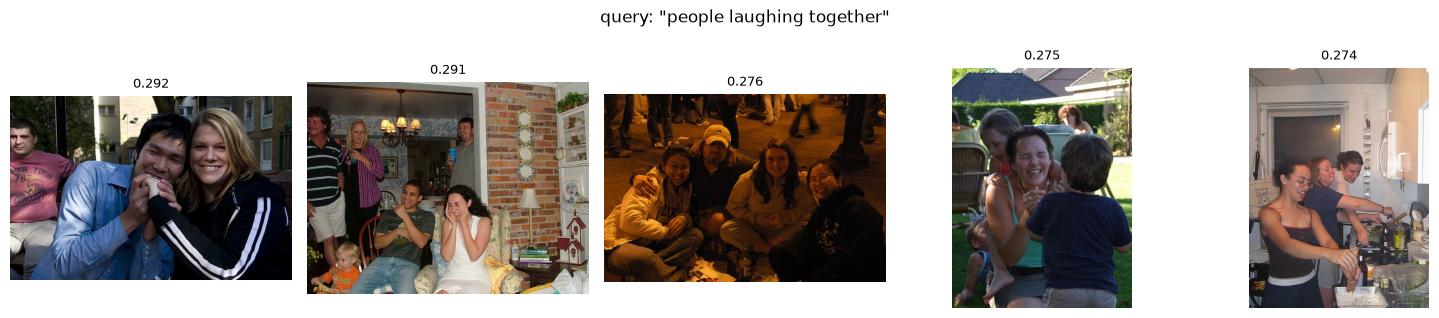

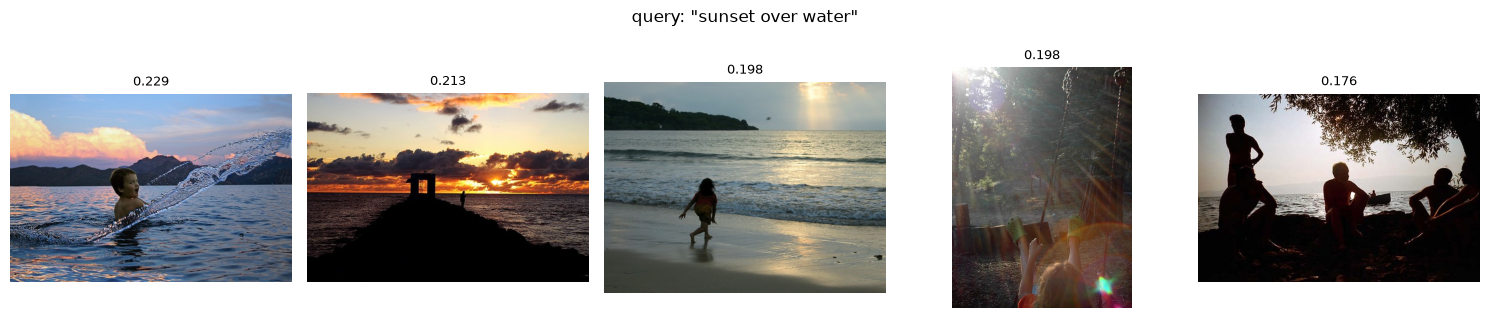

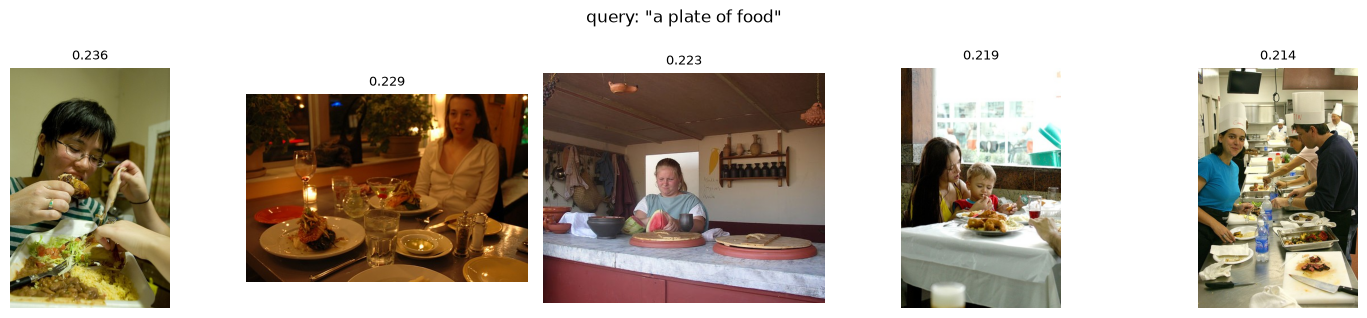

In [10]:
for q in ["a cat on a couch", "people laughing together", "sunset over water", "a plate of food"]:
    show_results(q, topn=5)

## Section 5 — The artifact: a 2D map of the photos

We reduce the 512-d image vectors to 2D with **UMAP** so similar photos sit together. To
give the map meaning we color each photo by a **zero-shot CLIP label**: score every image
against a few text prompts ("a photo of food", ...) and take the best match — no training.
This labelled plot is the deliverable artifact.


In [11]:
LABELS = ["people", "animals", "food", "landscape", "vehicle", "sport", "building", "indoor"]
label_vecs = embed_texts([f"a photo of {l}" for l in LABELS])   # (L, 512), normalized
sims = img_vectors @ label_vecs.T                               # (N, L) cosine sims
label_idx = sims.argmax(axis=1)                                 # argmax needs no softmax
point_labels = [LABELS[i] for i in label_idx]
print("auto-labeled", len(point_labels), "images across", len(set(point_labels)), "categories")

auto-labeled 1500 images across 8 categories


C:\Users\rasul\.conda\envs\clip-search\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


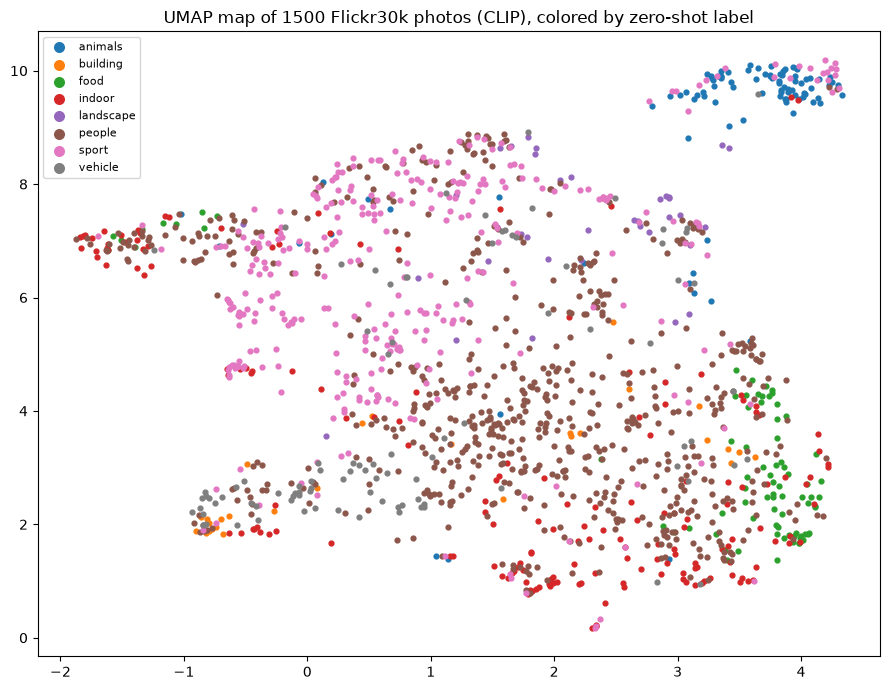

saved outputs\umap_map.png


In [12]:
import umap  # pip package is 'umap-learn', import name is 'umap'

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    metric="cosine", random_state=42)
coords = reducer.fit_transform(img_vectors)   # first call is slow (numba compiling) — normal

plt.figure(figsize=(9, 7))
for lab in sorted(set(point_labels)):
    m = np.array(point_labels) == lab
    plt.scatter(coords[m, 0], coords[m, 1], s=12, label=lab)
plt.legend(markerscale=2, fontsize=8, loc="best")
plt.title(f"UMAP map of {len(paths)} Flickr30k photos (CLIP), colored by zero-shot label")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "umap_map.png", dpi=130)
plt.show()
print("saved", OUTPUTS_DIR / "umap_map.png")

## Section 6 — Does it actually work? Recall@K

Flickr30k gives each photo human captions. We use each photo's caption as a query and check
whether **its own photo** lands in the top-K over all sampled images. Recall@1 / Recall@5
are honest numbers to show at the demo. With only ~1500 of 31k images a generic caption can
match a similar photo, so treat this as a **lower bound**.


In [13]:
def recall_at_k(image_vectors, caption_list, ks=(1, 5)):
    "text->image Recall@K: does each caption retrieve its own image in the top-K?"
    text_vecs = embed_texts(caption_list)          # (N, 512), normalized
    sims = text_vecs @ image_vectors.T             # (N_queries, N_images)
    gt = np.arange(len(caption_list))
    out = {}
    for k in ks:
        topk = np.argpartition(-sims, kth=k - 1, axis=1)[:, :k]
        out[k] = float((topk == gt[:, None]).any(axis=1).mean())
    return out

rec = recall_at_k(img_vectors, captions, ks=(1, 5))
print(f"Recall@1 = {rec[1]:.3f}   Recall@5 = {rec[5]:.3f}   (over {len(captions)} images, lower bound)")

Recall@1 = 0.718   Recall@5 = 0.912   (over 1500 images, lower bound)


## Section 7 — Export the index and build a local app

Save the image vectors + paths so the app never re-embeds. Then write `app.py`, a Streamlit
search box: type a phrase, get the top images. Only the **text** encoder runs at query time
(images are already embedded), so search stays instant.


In [14]:
np.save(OUTPUTS_DIR / "embeddings.npy", img_vectors)
np.save(OUTPUTS_DIR / "paths.npy", np.array(paths, dtype=object))
np.save(OUTPUTS_DIR / "captions.npy", np.array(captions, dtype=object))
print("saved embeddings.npy, paths.npy, captions.npy to", OUTPUTS_DIR)

saved embeddings.npy, paths.npy, captions.npy to outputs


In [15]:
app_code = r'''
import time
from pathlib import Path

import numpy as np
import torch, open_clip
import streamlit as st

MODEL_NAME, PRETRAINED = "ViT-B-32", "laion2b_s34b_b79k"
OUTPUTS = Path("outputs")

st.set_page_config(page_title="CLIP Image Search", page_icon="\U0001F50E", layout="wide")

st.markdown(
    """
    <style>
      .block-container { padding-top: 2.4rem; max-width: 1180px; }
      [data-testid="stImage"] img { border-radius: 14px; height: 200px; width: 100%; object-fit: cover; }
      .hero-title { font-size: 2.15rem; font-weight: 800; margin: 0; letter-spacing:-.5px; }
      .hero-sub { color: #6b7280; font-size: 1.03rem; margin:.15rem 0 .2rem; }
      .score { text-align:center; font-size:.82rem; color:#6b7280; margin:-2px 0 16px; }
      .score b { color:#111827; }
      div.stButton > button {
          border-radius:999px; border:1px solid #e5e7eb; padding:.26rem .95rem;
          background:#f9fafb; font-size:.86rem; font-weight:500;
      }
      div.stButton > button:hover { border-color:#7c3aed; color:#7c3aed; background:#faf5ff; }
    </style>
    """,
    unsafe_allow_html=True,
)

@st.cache_resource(show_spinner="Loading CLIP model...")
def load_model():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model, _, _ = open_clip.create_model_and_transforms(MODEL_NAME, pretrained=PRETRAINED, device=device)
    model.eval()
    tokenizer = open_clip.get_tokenizer(MODEL_NAME)
    return model, tokenizer, device

@st.cache_data(show_spinner=False)
def load_index():
    emb = np.load(OUTPUTS / "embeddings.npy")
    paths = np.load(OUTPUTS / "paths.npy", allow_pickle=True)
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-9)
    return emb.astype("float32"), paths

if not (OUTPUTS / "embeddings.npy").exists():
    st.error("No index found. Run clip_image_search.ipynb top to bottom first to create outputs/embeddings.npy.")
    st.stop()

model, tokenizer, device = load_model()
emb, paths = load_index()

@torch.no_grad()
def encode_query(text):
    tok = tokenizer([text]).to(device)
    v = model.encode_text(tok).float()
    v = v / v.norm(dim=-1, keepdim=True)
    return v.cpu().numpy()[0]

st.markdown('<p class="hero-title">\U0001F50E Semantic image search</p>', unsafe_allow_html=True)
st.markdown('<p class="hero-sub">Search photos by <b>meaning</b>, not filenames \u2014 powered by CLIP.</p>',
            unsafe_allow_html=True)

with st.sidebar:
    st.header("Settings")
    top_k = st.slider("Results", 3, 24, 12)
    n_cols = st.slider("Columns", 2, 6, 4)
    st.divider()
    st.metric("Photos in index", f"{len(paths):,}")
    st.caption(f"Model: {MODEL_NAME} / {PRETRAINED}")
    st.caption(f"Device: {device}")
    with st.expander("How it works"):
        st.write("CLIP maps your text and every image into the same 512-d space. We rank "
                 "images by cosine similarity to your query. Images are pre-embedded, so "
                 "each search is one dot product \u2014 instant.")

if "query" not in st.session_state:
    st.session_state.query = ""

st.write("Try an example:")
examples = ["a dog", "people laughing", "sunset over water", "a plate of food",
            "a person riding a bicycle", "children playing"]
for col, ex in zip(st.columns(len(examples)), examples):
    if col.button(ex, key=f"ex_{ex}", use_container_width=True):
        st.session_state.query = ex

query = st.text_input("Search", key="query", label_visibility="collapsed",
                      placeholder="e.g. a dog running on the beach")

if query:
    t0 = time.perf_counter()
    scores = emb @ encode_query(query)
    top = np.argsort(-scores)[:top_k]
    dt = (time.perf_counter() - t0) * 1000
    st.caption(f'Top {len(top)} of {len(paths):,} photos for "{query}"  \u00b7  {dt:.0f} ms')
    cols = st.columns(n_cols)
    for rank, idx in enumerate(top):
        with cols[rank % n_cols]:
            st.image(str(paths[idx]), width="stretch")
            st.markdown(f'<div class="score">#{rank+1} \u00b7 <b>{scores[idx]:.3f}</b></div>',
                        unsafe_allow_html=True)
else:
    st.info("Type a phrase above or tap an example to search the photo collection.")
'''
with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)
print("wrote app.py - run it with:  streamlit run app.py")

wrote app.py - run it with:  streamlit run app.py


## Run the app

In a terminal in this folder:

```
streamlit run app.py
```

Type a phrase and watch the photos it finds. What you built: CLIP → embeddings → cosine
search → a 2D map → a real app. Swap in any folder of images and the same recipe works.
